## Imports

In [1]:
from __future__ import annotations

import json
import random
import time

from contextlib import nullcontext
from copy import deepcopy
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb

from torch.utils.data import DataLoader, Dataset

from walmart_forecasting.data import load_merged_data
from walmart_forecasting.experiment import (
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
    save_architecture_result,
)
from walmart_forecasting.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    weighted_mae,
)
from walmart_forecasting.tracking import wandb_run
from walmart_forecasting.validation import (
    competition_like_holdout,
    expanding_window_splits,
)


pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

print("PyTorch version:", torch.__version__)
print("W&B version:", wandb.__version__)

PyTorch version: 2.13.0+cu130
W&B version: 0.28.0


## Configuration

In [2]:
ARCHITECTURE = "patchtst"
WANDB_GROUP = "PatchTST"

FORECAST_HORIZON = 13
FINAL_HOLDOUT_WEEKS = 39

HOLIDAY_WEIGHT = 5.0
NON_HOLIDAY_WEIGHT = 1.0

MIN_INPUT_COVERAGE = 0.80
GRADIENT_CLIP_NORM = 1.0

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = DEVICE.type == "cuda"
PIN_MEMORY = DEVICE.type == "cuda"

print("Device:", DEVICE)
print("Automatic mixed precision:", USE_AMP)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Device: cuda
Automatic mixed precision: True
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [3]:
def set_seed(
    seed: int = DEFAULT_RANDOM_SEED,
) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def trial_uses_amp(
    configuration: dict,
) -> bool:
    return (
        USE_AMP
        and bool(
            configuration.get(
                "use_amp",
                True,
            )
        )
    )


def amp_context(
    configuration: dict,
):
    if trial_uses_amp(configuration):
        return torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )

    return nullcontext()


set_seed()

## Data loading and validation

In [4]:
data = load_merged_data()

train = data.train.copy()
test = data.test.copy()

train["Date"] = pd.to_datetime(
    train["Date"]
)

test["Date"] = pd.to_datetime(
    test["Date"]
)

final_split = competition_like_holdout(
    train_data=train,
    test_data=test,
)

cv_splits = expanding_window_splits(
    data=final_split.train,
    n_splits=CV_FOLDS,
    validation_weeks=CV_VALIDATION_WEEKS,
)

series_count = (
    final_split.train[
        ["Store", "Dept"]
    ]
    .drop_duplicates()
    .shape[0]
)

assert (
    final_split.validation["Date"].nunique()
    == FINAL_HOLDOUT_WEEKS
)

assert (
    FINAL_HOLDOUT_WEEKS
    % FORECAST_HORIZON
    == 0
)

holiday_consistency = (
    train.groupby("Date")["IsHoliday"]
    .nunique()
    .max()
)

assert holiday_consistency == 1

print("Series count:", series_count)

Series count: 3306


In [5]:
split_summary = pd.DataFrame(
    [
        {
            "split": f"cv_fold_{fold_number}",
            "train_start": fold.train[
                "Date"
            ].min(),
            "train_end": fold.train[
                "Date"
            ].max(),
            "validation_start": (
                fold.validation["Date"].min()
            ),
            "validation_end": (
                fold.validation["Date"].max()
            ),
            "train_dates": (
                fold.train["Date"].nunique()
            ),
            "validation_dates": (
                fold.validation[
                    "Date"
                ].nunique()
            ),
            "train_rows": len(fold.train),
            "validation_rows": len(
                fold.validation
            ),
        }
        for fold_number, fold in enumerate(
            cv_splits,
            start=1,
        )
    ]
    + [
        {
            "split": "final_holdout",
            "train_start": (
                final_split.train["Date"].min()
            ),
            "train_end": (
                final_split.train["Date"].max()
            ),
            "validation_start": (
                final_split.validation[
                    "Date"
                ].min()
            ),
            "validation_end": (
                final_split.validation[
                    "Date"
                ].max()
            ),
            "train_dates": (
                final_split.train[
                    "Date"
                ].nunique()
            ),
            "validation_dates": (
                final_split.validation[
                    "Date"
                ].nunique()
            ),
            "train_rows": len(
                final_split.train
            ),
            "validation_rows": len(
                final_split.validation
            ),
        }
    ]
)

split_summary

,split,train_start,train_end,validation_start,validation_end,train_dates,validation_dates,train_rows,validation_rows
0,cv_fold_1,2010-02-05,2011-04-29,2011-05-06,2011-07-29,65,13,190674,38164
1,cv_fold_2,2010-02-05,2011-07-29,2011-08-05,2011-10-28,78,13,228838,38346
2,cv_fold_3,2010-02-05,2011-10-28,2011-11-04,2012-01-27,91,13,267184,38798
3,final_holdout,2010-02-05,2012-01-27,2012-02-03,2012-10-26,104,39,305982,115588


## Dense panel preparation

In [6]:
def build_panel_state(
    training_rows: pd.DataFrame,
    all_series: pd.DataFrame,
) -> dict:
    training_rows = training_rows.copy()

    training_rows["Date"] = pd.to_datetime(
        training_rows["Date"]
    )

    series_frame = (
        all_series[
            ["Store", "Dept"]
        ]
        .drop_duplicates()
        .sort_values(
            ["Store", "Dept"]
        )
        .reset_index(drop=True)
    )

    series_index = pd.MultiIndex.from_frame(
        series_frame
    )

    dates = pd.date_range(
        start=training_rows["Date"].min(),
        end=training_rows["Date"].max(),
        freq="W-FRI",
    )

    target_panel = (
        training_rows
        .pivot_table(
            index=["Store", "Dept"],
            columns="Date",
            values="Weekly_Sales",
            aggfunc="first",
        )
        .reindex(
            index=series_index,
            columns=dates,
        )
    )

    observed = (
        target_panel
        .notna()
        .to_numpy(dtype=np.float32)
    )

    values = (
        target_panel
        .fillna(0.0)
        .to_numpy(dtype=np.float32)
    )

    holiday_by_date = (
        training_rows
        .groupby("Date")["IsHoliday"]
        .max()
        .reindex(dates)
        .fillna(False)
        .astype(bool)
    )

    date_weights = np.where(
        holiday_by_date.to_numpy(),
        HOLIDAY_WEIGHT,
        NON_HOLIDAY_WEIGHT,
    ).astype(np.float32)

    pair_means = (
        training_rows
        .groupby(
            ["Store", "Dept"]
        )["Weekly_Sales"]
        .mean()
    )

    department_means = (
        training_rows
        .groupby("Dept")["Weekly_Sales"]
        .mean()
    )

    store_means = (
        training_rows
        .groupby("Store")["Weekly_Sales"]
        .mean()
    )

    global_mean = float(
        training_rows["Weekly_Sales"].mean()
    )

    return {
        "series_frame": series_frame,
        "series_index": series_index,
        "dates": dates,
        "values": values,
        "observed": observed,
        "date_weights": date_weights,
        "pair_means": pair_means,
        "department_means": department_means,
        "store_means": store_means,
        "global_mean": global_mean,
    }

## Sliding-window dataset

In [7]:
class PanelWindowDataset(Dataset):
    def __init__(
        self,
        panel_state: dict,
        input_length: int,
        horizon: int,
        min_input_coverage: float,
    ) -> None:
        self.state = panel_state
        self.input_length = input_length
        self.horizon = horizon
        self.samples = []

        number_of_series = (
            panel_state["observed"].shape[0]
        )

        number_of_dates = (
            panel_state["observed"].shape[1]
        )

        last_origin = (
            number_of_dates - horizon
        )

        for series_index in range(
            number_of_series
        ):
            observed = panel_state[
                "observed"
            ][series_index]

            for origin in range(
                input_length,
                last_origin + 1,
            ):
                input_mask = observed[
                    origin - input_length:
                    origin
                ]

                target_mask = observed[
                    origin:
                    origin + horizon
                ]

                if (
                    input_mask.mean()
                    >= min_input_coverage
                    and target_mask.sum() > 0
                ):
                    self.samples.append(
                        (
                            series_index,
                            origin,
                        )
                    )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(
        self,
        index: int,
    ):
        series_index, origin = (
            self.samples[index]
        )

        input_values = self.state[
            "values"
        ][
            series_index,
            origin - self.input_length:
            origin,
        ]

        input_mask = self.state[
            "observed"
        ][
            series_index,
            origin - self.input_length:
            origin,
        ]

        targets = self.state[
            "values"
        ][
            series_index,
            origin:
            origin + self.horizon,
        ]

        target_mask = self.state[
            "observed"
        ][
            series_index,
            origin:
            origin + self.horizon,
        ]

        horizon_weights = self.state[
            "date_weights"
        ][
            origin:
            origin + self.horizon
        ]

        return (
            torch.from_numpy(input_values),
            torch.from_numpy(input_mask),
            torch.from_numpy(targets),
            torch.from_numpy(target_mask),
            torch.from_numpy(
                horizon_weights
            ),
        )

## PatchTST architecture

In [8]:
class PatchTSTModel(nn.Module):
    def __init__(
        self,
        input_length: int,
        horizon: int,
        patch_length: int,
        stride: int,
        d_model: int,
        n_heads: int,
        encoder_layers: int,
        d_ff: int,
        dropout: float,
        head_dropout: float,
        use_revin: bool,
    ) -> None:
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError(
                "d_model must be divisible "
                "by n_heads."
            )

        if patch_length > (
            input_length + stride
        ):
            raise ValueError(
                "Patch length is too large."
            )

        self.input_length = input_length
        self.horizon = horizon
        self.patch_length = patch_length
        self.stride = stride
        self.use_revin = use_revin

        self.number_of_patches = (
            (
                input_length
                + stride
                - patch_length
            )
            // stride
            + 1
        )

        # Each patch contains sales values
        # and the corresponding observation mask.
        self.patch_projection = nn.Linear(
            2 * patch_length,
            d_model,
        )

        self.position_embedding = (
            nn.Parameter(
                torch.zeros(
                    1,
                    self.number_of_patches,
                    d_model,
                )
            )
        )

        self.input_dropout = nn.Dropout(
            dropout
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=d_ff,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=encoder_layers,
            norm=nn.LayerNorm(d_model),
            enable_nested_tensor=False,
        )

        self.head = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Dropout(head_dropout),
            nn.Linear(
                self.number_of_patches
                * d_model,
                horizon,
            ),
        )

        self._reset_parameters()

    def _reset_parameters(self) -> None:
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(
                    module.weight
                )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

            elif isinstance(
                module,
                nn.LayerNorm,
            ):
                nn.init.ones_(
                    module.weight
                )

                nn.init.zeros_(
                    module.bias
                )

        for layer in self.encoder.layers:
            nn.init.xavier_uniform_(
                layer.self_attn.in_proj_weight
            )

            if (
                layer.self_attn.in_proj_bias
                is not None
            ):
                nn.init.zeros_(
                    layer.self_attn.in_proj_bias
                )

        nn.init.trunc_normal_(
            self.position_embedding,
            std=0.02,
        )

    def _normalize(
        self,
        values: torch.Tensor,
        mask: torch.Tensor,
    ) -> tuple[
        torch.Tensor,
        torch.Tensor,
        torch.Tensor,
    ]:
        mask = mask.to(values.dtype)

        if not self.use_revin:
            mean = torch.zeros(
                (
                    values.shape[0],
                    1,
                ),
                dtype=values.dtype,
                device=values.device,
            )

            standard_deviation = torch.ones(
                (
                    values.shape[0],
                    1,
                ),
                dtype=values.dtype,
                device=values.device,
            )

            return (
                values * mask,
                mean,
                standard_deviation,
            )

        count = (
            mask.sum(
                dim=1,
                keepdim=True,
            )
            .clamp_min(1.0)
        )

        mean = (
            (values * mask)
            .sum(
                dim=1,
                keepdim=True,
            )
            / count
        )

        centered = (
            values - mean
        ) * mask

        variance = (
            centered.pow(2)
            .sum(
                dim=1,
                keepdim=True,
            )
            / count
        )

        standard_deviation = (
            variance + 1e-5
        ).sqrt()

        normalized = (
            centered
            / standard_deviation
        )

        return (
            normalized,
            mean,
            standard_deviation,
        )

    def forward(
        self,
        values: torch.Tensor,
        mask: torch.Tensor,
    ) -> torch.Tensor:
        (
            normalized,
            mean,
            standard_deviation,
        ) = self._normalize(
            values=values,
            mask=mask,
        )

        padded_values = F.pad(
            normalized.unsqueeze(1),
            (
                0,
                self.stride,
            ),
            mode="replicate",
        ).squeeze(1)

        padded_mask = F.pad(
            mask.unsqueeze(1),
            (
                0,
                self.stride,
            ),
            mode="replicate",
        ).squeeze(1)

        value_patches = (
            padded_values.unfold(
                dimension=1,
                size=self.patch_length,
                step=self.stride,
            )
        )

        mask_patches = (
            padded_mask.unfold(
                dimension=1,
                size=self.patch_length,
                step=self.stride,
            )
        )

        patch_features = torch.cat(
            [
                value_patches,
                mask_patches,
            ],
            dim=-1,
        )

        tokens = self.patch_projection(
            patch_features
        )

        tokens = (
            tokens
            + self.position_embedding[
                :,
                :tokens.shape[1],
            ]
        )

        tokens = self.input_dropout(
            tokens
        )

        encoded = self.encoder(tokens)

        normalized_forecast = self.head(
            encoded
        )

        forecast = (
            normalized_forecast
            * standard_deviation
            + mean
        )

        return forecast

## Model construction

In [9]:
def build_model(
    configuration: dict,
) -> PatchTSTModel:
    return PatchTSTModel(
        input_length=configuration[
            "input_length"
        ],
        horizon=FORECAST_HORIZON,
        patch_length=configuration[
            "patch_length"
        ],
        stride=configuration["stride"],
        d_model=configuration["d_model"],
        n_heads=configuration["n_heads"],
        encoder_layers=configuration[
            "encoder_layers"
        ],
        d_ff=configuration["d_ff"],
        dropout=configuration["dropout"],
        head_dropout=configuration[
            "head_dropout"
        ],
        use_revin=configuration[
            "use_revin"
        ],
    )


def count_parameters(
    model: nn.Module,
) -> int:
    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )


def calculate_patch_count(
    configuration: dict,
) -> int:
    return (
        (
            configuration["input_length"]
            + configuration["stride"]
            - configuration["patch_length"]
        )
        // configuration["stride"]
        + 1
    )

## Weighted training loss

In [10]:
def weighted_mae_loss(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    target_mask: torch.Tensor,
    horizon_weights: torch.Tensor,
) -> torch.Tensor:
    predictions = predictions.float()
    targets = targets.float()
    target_mask = target_mask.float()
    horizon_weights = (
        horizon_weights.float()
    )

    combined_weights = (
        target_mask
        * horizon_weights
    )

    weighted_error = (
        (predictions - targets)
        .abs()
        * combined_weights
    )

    return (
        weighted_error.sum()
        / combined_weights
        .sum()
        .clamp_min(1.0)
    )

## Fallback predictions

In [11]:
def make_fallback_predictions(
    rows: pd.DataFrame,
    panel_state: dict,
) -> np.ndarray:
    pair_keys = pd.MultiIndex.from_frame(
        rows[
            ["Store", "Dept"]
        ]
    )

    predictions = pd.Series(
        panel_state[
            "pair_means"
        ]
        .reindex(pair_keys)
        .to_numpy(),
        index=rows.index,
        dtype=float,
    )

    predictions = predictions.fillna(
        rows["Dept"].map(
            panel_state[
                "department_means"
            ]
        )
    )

    predictions = predictions.fillna(
        rows["Store"].map(
            panel_state["store_means"]
        )
    )

    predictions = predictions.fillna(
        panel_state["global_mean"]
    )

    return predictions.to_numpy(
        dtype=np.float32
    )

## One-block forecasting

In [12]:
@torch.no_grad()
def forecast_one_block(
    model: nn.Module,
    panel_state: dict,
    forecast_dates: pd.DatetimeIndex,
    configuration: dict,
) -> tuple[
    pd.DataFrame,
    np.ndarray,
]:
    model.eval()

    input_length = configuration[
        "input_length"
    ]

    if len(forecast_dates) != (
        FORECAST_HORIZON
    ):
        raise ValueError(
            "forecast_dates must contain "
            f"{FORECAST_HORIZON} dates."
        )

    recent_coverage = (
        panel_state["observed"][
            :,
            -input_length:,
        ]
        .mean(axis=1)
    )

    eligible = (
        recent_coverage
        >= MIN_INPUT_COVERAGE
    )

    eligible_indices = np.flatnonzero(
        eligible
    )

    predictions = np.full(
        (
            len(
                panel_state[
                    "series_frame"
                ]
            ),
            FORECAST_HORIZON,
        ),
        np.nan,
        dtype=np.float32,
    )

    batch_size = configuration[
        "batch_size"
    ]

    for start in range(
        0,
        len(eligible_indices),
        batch_size,
    ):
        batch_indices = eligible_indices[
            start:
            start + batch_size
        ]

        batch_values = torch.from_numpy(
            panel_state["values"][
                batch_indices,
                -input_length:,
            ]
        ).to(
            DEVICE,
            non_blocking=True,
        )

        batch_mask = torch.from_numpy(
            panel_state["observed"][
                batch_indices,
                -input_length:,
            ]
        ).to(
            DEVICE,
            non_blocking=True,
        )

        with amp_context(configuration):
            batch_predictions = model(
                batch_values,
                batch_mask,
            )

        batch_predictions = (
            batch_predictions
            .float()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        if not np.isfinite(
            batch_predictions
        ).all():
            raise FloatingPointError(
                "PatchTST produced "
                "non-finite predictions "
                f"for trial configuration: "
                f"use_revin="
                f"{configuration['use_revin']}, "
                f"use_amp="
                f"{configuration.get('use_amp', True)}."
            )

        predictions[
            batch_indices
        ] = batch_predictions

    eligible_series = (
        panel_state["series_frame"]
        .iloc[eligible_indices]
        .reset_index(drop=True)
    )

    prediction_frame = (
        eligible_series
        .loc[
            eligible_series.index.repeat(
                FORECAST_HORIZON
            )
        ]
        .reset_index(drop=True)
    )

    prediction_frame["Date"] = np.tile(
        forecast_dates.to_numpy(),
        len(eligible_series),
    )

    prediction_frame[
        "ModelPrediction"
    ] = (
        predictions[
            eligible_indices
        ]
        .reshape(-1)
    )

    return prediction_frame, eligible

## Validation evaluation

In [13]:
def evaluate_one_horizon(
    model: nn.Module,
    panel_state: dict,
    validation_rows: pd.DataFrame,
    configuration: dict,
) -> tuple[
    dict[str, float],
    pd.DataFrame,
]:
    validation_rows = (
        validation_rows
        .sort_values(
            ["Date", "Store", "Dept"]
        )
        .reset_index(drop=True)
        .copy()
    )

    validation_dates = pd.DatetimeIndex(
        validation_rows["Date"]
        .drop_duplicates()
        .sort_values()
    )

    prediction_frame, _ = (
        forecast_one_block(
            model=model,
            panel_state=panel_state,
            forecast_dates=(
                validation_dates
            ),
            configuration=configuration,
        )
    )

    result = validation_rows.merge(
        prediction_frame,
        on=[
            "Store",
            "Dept",
            "Date",
        ],
        how="left",
        validate="many_to_one",
    )

    fallback_predictions = (
        make_fallback_predictions(
            rows=result,
            panel_state=panel_state,
        )
    )

    model_mask = result[
        "ModelPrediction"
    ].notna()

    result["Prediction"] = np.where(
        model_mask,
        result["ModelPrediction"],
        fallback_predictions,
    )

    result["AbsoluteError"] = (
        result["Weekly_Sales"]
        - result["Prediction"]
    ).abs()

    metrics = {
        "wmae": weighted_mae(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result["Prediction"],
            is_holiday=result[
                "IsHoliday"
            ],
        ),
        "mae": mean_absolute_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result["Prediction"],
        ),
        "rmse": root_mean_squared_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result["Prediction"],
        ),
        "neural_coverage": float(
            model_mask.mean()
        ),
    }

    return metrics, result

## Fold training

In [14]:
def train_one_fold(
    configuration: dict,
    fold,
    fold_number: int,
    run,
) -> dict:
    set_seed(
        DEFAULT_RANDOM_SEED
        + fold_number
    )

    all_series = pd.concat(
        [
            fold.train[
                ["Store", "Dept"]
            ],
            fold.validation[
                ["Store", "Dept"]
            ],
        ],
        ignore_index=True,
    )

    panel_state = build_panel_state(
        training_rows=fold.train,
        all_series=all_series,
    )

    dataset = PanelWindowDataset(
        panel_state=panel_state,
        input_length=configuration[
            "input_length"
        ],
        horizon=FORECAST_HORIZON,
        min_input_coverage=(
            MIN_INPUT_COVERAGE
        ),
    )

    if len(dataset) == 0:
        raise RuntimeError(
            "No valid training windows "
            f"for fold {fold_number}."
        )

    generator = torch.Generator()

    generator.manual_seed(
        DEFAULT_RANDOM_SEED
        + fold_number
    )

    loader = DataLoader(
        dataset,
        batch_size=configuration[
            "batch_size"
        ],
        shuffle=True,
        num_workers=0,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        generator=generator,
    )

    model = build_model(
        configuration
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=configuration[
            "learning_rate"
        ],
        weight_decay=configuration[
            "weight_decay"
        ],
    )

    scaler = None

    if trial_uses_amp(configuration):
        scaler = torch.amp.GradScaler(
            "cuda"
        )

    parameter_count = count_parameters(
        model
    )

    best_wmae = float("inf")
    best_epoch = 0
    best_state = None

    epochs_without_improvement = 0
    history = []

    fit_start = time.perf_counter()

    for epoch in range(
        1,
        configuration[
            "max_epochs"
        ] + 1,
    ):
        model.train()

        weighted_error_sum = 0.0
        weight_sum = 0.0

        for (
            input_values,
            input_mask,
            targets,
            target_mask,
            horizon_weights,
        ) in loader:
            input_values = input_values.to(
                DEVICE,
                non_blocking=True,
            )

            input_mask = input_mask.to(
                DEVICE,
                non_blocking=True,
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True,
            )

            target_mask = target_mask.to(
                DEVICE,
                non_blocking=True,
            )

            horizon_weights = (
                horizon_weights.to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with amp_context(configuration):
                predictions = model(
                    input_values,
                    input_mask,
                )

                loss = weighted_mae_loss(
                    predictions=predictions,
                    targets=targets,
                    target_mask=(
                        target_mask
                    ),
                    horizon_weights=(
                        horizon_weights
                    ),
                )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite training loss "
                    f"in fold {fold_number}, "
                    f"epoch {epoch}. "
                    f"use_revin="
                    f"{configuration['use_revin']}, "
                    f"use_amp="
                    f"{configuration.get('use_amp', True)}."
                )

            if scaler is not None:
                scaler.scale(
                    loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=(
                        GRADIENT_CLIP_NORM
                    ),
                )

                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=(
                        GRADIENT_CLIP_NORM
                    ),
                )

                optimizer.step()

            with torch.no_grad():
                combined_weights = (
                    target_mask.float()
                    * horizon_weights.float()
                )

                raw_absolute_error = (
                    predictions.float()
                    - targets.float()
                ).abs()

                weighted_error_sum += (
                    raw_absolute_error
                    .mul(combined_weights)
                    .sum()
                    .item()
                )

                weight_sum += (
                    combined_weights
                    .sum()
                    .item()
                )

        train_window_wmae = (
            weighted_error_sum
            / max(weight_sum, 1.0)
        )

        validation_metrics, _ = (
            evaluate_one_horizon(
                model=model,
                panel_state=panel_state,
                validation_rows=(
                    fold.validation
                ),
                configuration=(
                    configuration
                ),
            )
        )

        validation_wmae = (
            validation_metrics["wmae"]
        )

        history.append(
            {
                "epoch": epoch,
                "train_window_wmae": (
                    train_window_wmae
                ),
                "validation_wmae": (
                    validation_wmae
                ),
                "validation_mae": (
                    validation_metrics[
                        "mae"
                    ]
                ),
                "validation_rmse": (
                    validation_metrics[
                        "rmse"
                    ]
                ),
                "neural_coverage": (
                    validation_metrics[
                        "neural_coverage"
                    ]
                ),
            }
        )

        global_step = (
            (fold_number - 1)
            * configuration[
                "max_epochs"
            ]
            + epoch
        )

        run.log(
            {
                "fold": fold_number,
                "epoch": epoch,
                (
                    f"fold_{fold_number}/"
                    "train_window_wmae"
                ): train_window_wmae,
                (
                    f"fold_{fold_number}/"
                    "validation_wmae"
                ): validation_wmae,
                (
                    f"fold_{fold_number}/"
                    "validation_mae"
                ): validation_metrics[
                    "mae"
                ],
                (
                    f"fold_{fold_number}/"
                    "validation_rmse"
                ): validation_metrics[
                    "rmse"
                ],
                (
                    f"fold_{fold_number}/"
                    "neural_coverage"
                ): validation_metrics[
                    "neural_coverage"
                ],
            },
            step=global_step,
        )

        if validation_wmae < best_wmae:
            best_wmae = validation_wmae
            best_epoch = epoch

            best_state = {
                name: value
                .detach()
                .cpu()
                .clone()
                for name, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= configuration["patience"]
        ):
            break

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    if best_state is None:
        raise RuntimeError(
            "No valid best checkpoint "
            "was created."
        )

    model.load_state_dict(best_state)

    final_metrics, predictions = (
        evaluate_one_horizon(
            model=model,
            panel_state=panel_state,
            validation_rows=(
                fold.validation
            ),
            configuration=configuration,
        )
    )

    history_frame = pd.DataFrame(
        history
    )

    best_history_row = (
        history_frame
        .loc[
            history_frame["epoch"]
            == best_epoch
        ]
        .iloc[0]
    )

    result = {
        "fold": fold_number,
        "wmae": final_metrics["wmae"],
        "mae": final_metrics["mae"],
        "rmse": final_metrics["rmse"],
        "neural_coverage": (
            final_metrics[
                "neural_coverage"
            ]
        ),
        "best_epoch": best_epoch,
        "train_window_wmae_at_best": (
            float(
                best_history_row[
                    "train_window_wmae"
                ]
            )
        ),
        "training_windows": len(dataset),
        "parameter_count": (
            parameter_count
        ),
        "fit_seconds": fit_seconds,
        "epochs_ran": len(
            history_frame
        ),
        "history": history_frame,
        "predictions": predictions,
    }

    del model
    del optimizer

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

## Cross-validation experiment runner

In [15]:
def run_cv_trial(
    trial: dict,
) -> tuple[
    dict,
    pd.DataFrame,
    dict[int, pd.DataFrame],
]:
    run_name = make_run_name(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        trial_name=trial[
            "trial_name"
        ],
    )

    parameters = build_common_parameters(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        preprocessing=trial[
            "preprocessing"
        ],
        evaluation_scope="full_dataset",
        forecast_strategy=(
            "native_multi_horizon_13"
        ),
        series_count=series_count,
        extra_parameters={
            key: value
            for key, value
            in trial.items()
            if key not in {
                "trial_id",
                "trial_name",
                "feature_set",
                "preprocessing",
            }
        },
    )

    fold_results = []
    fold_histories = {}

    with wandb_run(
        run_name=run_name,
        group=WANDB_GROUP,
        job_type="tuning",
        config=parameters,
        tags=[
            "patchtst",
            "tuning",
            "full_dataset",
            trial[
                "capacity_profile"
            ],
        ],
    ) as run:
        for fold_number, fold in enumerate(
            cv_splits,
            start=1,
        ):
            fold_result = train_one_fold(
                configuration=trial,
                fold=fold,
                fold_number=fold_number,
                run=run,
            )

            fold_histories[
                fold_number
            ] = fold_result.pop(
                "history"
            )

            fold_result.pop(
                "predictions"
            )

            fold_results.append(
                fold_result
            )

            print(
                f"{trial['trial_id']} | "
                f"fold={fold_number} | "
                f"WMAE="
                f"{fold_result['wmae']:,.2f} | "
                f"epoch="
                f"{fold_result['best_epoch']} | "
                f"coverage="
                f"{fold_result['neural_coverage']:.2%}"
            )

        fold_frame = pd.DataFrame(
            fold_results
        )

        summary = {
            "trial_id": trial[
                "trial_id"
            ],
            "trial_name": trial[
                "trial_name"
            ],
            "capacity_profile": trial[
                "capacity_profile"
            ],
            "feature_set": trial[
                "feature_set"
            ],
            "preprocessing": trial[
                "preprocessing"
            ],
            "input_length": trial[
                "input_length"
            ],
            "patch_length": trial[
                "patch_length"
            ],
            "stride": trial["stride"],
            "patch_count": (
                calculate_patch_count(
                    trial
                )
            ),
            "d_model": trial["d_model"],
            "n_heads": trial["n_heads"],
            "encoder_layers": trial[
                "encoder_layers"
            ],
            "parameter_count": int(
                fold_frame[
                    "parameter_count"
                ].iloc[0]
            ),
            (
                "cv_train_window_"
                "wmae_mean"
            ): float(
                fold_frame[
                    "train_window_"
                    "wmae_at_best"
                ].mean()
            ),
            "cv_wmae_mean": float(
                fold_frame[
                    "wmae"
                ].mean()
            ),
            "cv_wmae_std": float(
                fold_frame[
                    "wmae"
                ].std(ddof=0)
            ),
            "cv_mae_mean": float(
                fold_frame[
                    "mae"
                ].mean()
            ),
            "cv_rmse_mean": float(
                fold_frame[
                    "rmse"
                ].mean()
            ),
            "best_epoch_median": int(
                np.median(
                    fold_frame[
                        "best_epoch"
                    ]
                )
            ),
            "neural_coverage_mean": float(
                fold_frame[
                    "neural_coverage"
                ].mean()
            ),
            "training_windows_mean": float(
                fold_frame[
                    "training_windows"
                ].mean()
            ),
            "fit_seconds": float(
                fold_frame[
                    "fit_seconds"
                ].sum()
            ),
        }

        for key, value in (
            summary.items()
        ):
            if isinstance(
                value,
                (
                    int,
                    float,
                    np.integer,
                    np.floating,
                ),
            ):
                run.summary[key] = value

        run.log(
            {
                "fold_results": (
                    wandb.Table(
                        dataframe=fold_frame
                    )
                )
            }
        )

    return (
        summary,
        fold_frame,
        fold_histories,
    )

## Context and patch-geometry experiments

In [16]:
BASE_CONFIGURATION = {
    "input_length": 52,
    "patch_length": 8,
    "stride": 4,
    "d_model": 128,
    "n_heads": 4,
    "encoder_layers": 3,
    "d_ff": 256,
    "dropout": 0.10,
    "head_dropout": 0.10,
    "use_revin": True,
    "use_amp": True,
    "learning_rate": 0.0005,
    "weight_decay": 0.0001,
    "batch_size": 512,
    "max_epochs": 50,
    "patience": 8,
}


patch_trials = [
    {
        "trial_id": (
            "context39_patch8_stride4"
        ),
        "trial_name": (
            "context39_patch8"
        ),
        "capacity_profile": (
            "patch_geometry"
        ),
        "feature_set": (
            "target_only_context39_"
            "patch8_stride4_v1"
        ),
        "preprocessing": (
            "masked_panel_revin_v1"
        ),
        **deepcopy(BASE_CONFIGURATION),
        "input_length": 39,
    },
    {
        "trial_id": (
            "context52_patch4_stride2"
        ),
        "trial_name": (
            "patch4_stride2"
        ),
        "capacity_profile": (
            "patch_geometry"
        ),
        "feature_set": (
            "target_only_context52_"
            "patch4_stride2_v1"
        ),
        "preprocessing": (
            "masked_panel_revin_v1"
        ),
        **deepcopy(BASE_CONFIGURATION),
        "patch_length": 4,
        "stride": 2,
    },
    {
        "trial_id": (
            "context52_patch8_stride4"
        ),
        "trial_name": (
            "patch8_stride4"
        ),
        "capacity_profile": (
            "patch_geometry"
        ),
        "feature_set": (
            "target_only_context52_"
            "patch8_stride4_v1"
        ),
        "preprocessing": (
            "masked_panel_revin_v1"
        ),
        **deepcopy(BASE_CONFIGURATION),
    },
    {
        "trial_id": (
            "context52_patch13_stride4"
        ),
        "trial_name": (
            "patch13_stride4"
        ),
        "capacity_profile": (
            "patch_geometry"
        ),
        "feature_set": (
            "target_only_context52_"
            "patch13_stride4_v1"
        ),
        "preprocessing": (
            "masked_panel_revin_v1"
        ),
        **deepcopy(BASE_CONFIGURATION),
        "patch_length": 13,
        "stride": 4,
    },
]


trial_registry = {
    trial["trial_id"]: trial
    for trial in patch_trials
}

trial_summaries = []
trial_fold_results = {}
trial_histories = {}

In [17]:
for trial in patch_trials:
    (
        summary,
        fold_frame,
        histories,
    ) = run_cv_trial(trial)

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

    trial_histories[
        trial["trial_id"]
    ] = histories


patch_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

patch_results[
    [
        "trial_id",
        "input_length",
        "patch_length",
        "stride",
        "patch_count",
        "parameter_count",
        "cv_wmae_mean",
        "cv_wmae_std",
        "best_epoch_median",
        "neural_coverage_mean",
        "fit_seconds",
    ]
]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run r6nvj3bn
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260711_221436-r6nvj3bn
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run patchtst__tuning__target_only_context39_patch8_stride4_v1__context39_patch8__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/r6nvj3bn


context39_patch8_stride4 | fold=1 | WMAE=2,629.85 | epoch=2 | coverage=96.51%
context39_patch8_stride4 | fold=2 | WMAE=2,103.61 | epoch=6 | coverage=96.08%
context39_patch8_stride4 | fold=3 | WMAE=4,376.63 | epoch=25 | coverage=95.06%


wandb: uploading artifact run-r6nvj3bn-fold_results; updating run metadata
wandb: uploading artifact run-r6nvj3bn-fold_results
wandb: uploading media/table/fold_results_133_256c6a8ad3fd46b7e5d3.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 56-56, summary
wandb: 
wandb: Run history:
wandb:                    epoch ▁▁▁▂▂▃▃▁▁▂▂▂▃▃▃▄▁▁▂▂▃▃▃▃▃▄▄▅▅▅▆▆▆▆▆▇▇▇██
wandb:                     fold ▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅██████████████████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae █▅▄▄▃▃▂▂▁▁
wandb:    fold_1/validation_mae ▁▁▄▄▃▂▃██▅
wandb:   fold_1/validation_rmse ▂▁▄▃▃▁▂▇█▄
wandb:   fold_1/validation_wmae ▁▁▄▄▃▂▃██▅
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █▅▄▃▃▂▂▂▂▂▁▁▁▁
wandb:    fold_2/validation_mae ▅█▄▄▄▁▄▁▂▁▄▂▇▄
wandb:                       +7 ...
wandb: 
wandb: Run summary:
wandb:         best_epoch_median 6
wandb:  

context52_patch4_stride2 | fold=1 | WMAE=2,094.87 | epoch=14 | coverage=96.20%
context52_patch4_stride2 | fold=2 | WMAE=1,674.11 | epoch=10 | coverage=95.78%
context52_patch4_stride2 | fold=3 | WMAE=3,215.33 | epoch=6 | coverage=95.29%


wandb: uploading artifact run-w969qc4l-fold_results; updating run metadata
wandb: uploading artifact run-w969qc4l-fold_results
wandb: uploading media/table/fold_results_114_2c5e30dcb0f236f4f17a.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 53-53, summary
wandb: 
wandb: Run history:
wandb:                    epoch ▁▁▂▂▂▃▃▄▄▅▅▆▆▇▇██▁▁▂▂▃▃▃▄▅▅▆▆▆▁▁▂▂▃▃▄▄▄▅
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅██████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae ██▅▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_1/validation_mae ██▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_rmse ██▄▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_wmae ██▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █▅▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:    fold_2/validation_mae ██▄▃▂▄▃▂▂▁▁▁▁▂▁▁▁▂
wandb:                       +7 ...
wandb: 
wandb: Run summary:
wandb:         best_epoch_medi

context52_patch8_stride4 | fold=1 | WMAE=1,986.91 | epoch=25 | coverage=96.20%
context52_patch8_stride4 | fold=2 | WMAE=1,680.47 | epoch=12 | coverage=95.78%
context52_patch8_stride4 | fold=3 | WMAE=3,156.26 | epoch=25 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-dthxiyw2-fold_results
wandb: uploading artifact run-dthxiyw2-fold_results
wandb: uploading media/table/fold_results_133_83fece751decee5a66bf.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 83-85, summary
wandb: 
wandb: Run history:
wandb:                    epoch ▁▁▁▂▂▃▃▃▄▄▅▆▇██▂▂▂▃▃▃▄▅▅▅▁▂▂▂▃▄▄▄▅▅▆▆▇▇█
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅██████████████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae ██▆▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_1/validation_mae ██▄▃▂▂▂▂▂▂▂▂▁▂▂▁▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_rmse ██▄▃▂▂▂▂▂▂▂▂▁▂▁▁▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_wmae ██▄▃▂▂▂▂▂▂▂▂▁▂▂▁▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_2/validation_mae █▄▆▃▃▄▃▂▂▂▂▁▁▂▁▁▁▁▁▂
wandb:                       +7 .

context52_patch13_stride4 | fold=1 | WMAE=2,114.19 | epoch=12 | coverage=96.20%
context52_patch13_stride4 | fold=2 | WMAE=1,678.05 | epoch=19 | coverage=95.78%
context52_patch13_stride4 | fold=3 | WMAE=3,003.00 | epoch=26 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-vsxk4e50-fold_results
wandb: uploading artifact run-vsxk4e50-fold_results
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:                    epoch ▁▁▂▂▂▄▄▄▄▅▁▁▁▂▂▂▃▄▄▅▆▆▁▁▁▂▂▂▃▃▄▄▅▆▆▇▇▇██
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅█████████████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae ██▇▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
wandb:    fold_1/validation_mae ██▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_rmse ██▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_wmae ██▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █▅▄▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_2/validation_mae █▅█▄▂▄▂▂▂▄▁▂▂▂▂▂▃▃▁▃▃▂▂▂▁▁▂
wandb:                       +7 ...
wandb: 
wandb: Run summary:
wandb:         best_epoch_median 19
wandb:               cv_mae_mean 2117.53084
wandb:              cv_rmse_mean 5042.95133
wandb: 

,trial_id,input_length,patch_length,stride,patch_count,parameter_count,cv_wmae_mean,cv_wmae_std,best_epoch_median,neural_coverage_mean,fit_seconds
0,context52_patch13_stride4,52,13,4,11,420877,"2,265.0828",551.3309,19,0.9575,268.8754
1,context52_patch8_stride4,52,8,4,13,423181,"2,274.5484",635.8942,25,0.9575,264.4932
2,context52_patch4_stride2,52,4,2,26,445453,"2,328.1025",650.4526,10,0.9575,160.8373
3,context39_patch8_stride4,39,8,4,9,416013,"3,036.6957",971.5293,6,0.9588,285.7702


## Best patch geometry

In [18]:
best_patch_trial_id = (
    patch_results.iloc[0][
        "trial_id"
    ]
)

best_patch_trial = deepcopy(
    trial_registry[
        best_patch_trial_id
    ]
)

print(
    "Selected patch trial:",
    best_patch_trial_id,
)

best_patch_trial

Selected patch trial: context52_patch13_stride4


{'trial_id': 'context52_patch13_stride4',
 'trial_name': 'patch13_stride4',
 'capacity_profile': 'patch_geometry',
 'feature_set': 'target_only_context52_patch13_stride4_v1',
 'preprocessing': 'masked_panel_revin_v1',
 'input_length': 52,
 'patch_length': 13,
 'stride': 4,
 'd_model': 128,
 'n_heads': 4,
 'encoder_layers': 3,
 'd_ff': 256,
 'dropout': 0.1,
 'head_dropout': 0.1,
 'use_revin': True,
 'use_amp': True,
 'learning_rate': 0.0005,
 'weight_decay': 0.0001,
 'batch_size': 512,
 'max_epochs': 50,
 'patience': 8}

## Capacity and optimization experiments

In [19]:
small_trial = deepcopy(
    best_patch_trial
)

small_trial.update(
    {
        "trial_id": (
            "capacity_small"
        ),
        "trial_name": (
            "small_underfit"
        ),
        "capacity_profile": (
            "small_underfit"
        ),
        "d_model": 64,
        "n_heads": 4,
        "encoder_layers": 2,
        "d_ff": 128,
    }
)


wide_trial = deepcopy(
    best_patch_trial
)

wide_trial.update(
    {
        "trial_id": (
            "capacity_wide"
        ),
        "trial_name": "wide_256",
        "capacity_profile": (
            "wide"
        ),
        "d_model": 256,
        "n_heads": 8,
        "encoder_layers": 3,
        "d_ff": 512,
        "batch_size": 256,
    }
)


deep_trial = deepcopy(
    best_patch_trial
)

deep_trial.update(
    {
        "trial_id": (
            "capacity_deep_regularized"
        ),
        "trial_name": (
            "deep_regularized"
        ),
        "capacity_profile": (
            "deep_regularized"
        ),
        "encoder_layers": 5,
        "dropout": 0.20,
        "head_dropout": 0.20,
    }
)


no_revin_trial = deepcopy(
    best_patch_trial
)

no_revin_trial.update(
    {
        "trial_id": (
            "normalization_no_revin"
        ),
        "trial_name": "no_revin",
        "capacity_profile": (
            "normalization_ablation"
        ),
        "preprocessing": (
            "masked_panel_no_revin_v1"
        ),
        "use_revin": False,
        "use_amp": False,
    }
)


lower_lr_trial = deepcopy(
    best_patch_trial
)

lower_lr_trial.update(
    {
        "trial_id": (
            "optimization_lr_0002"
        ),
        "trial_name": (
            "learning_rate_0002"
        ),
        "capacity_profile": (
            "lower_learning_rate"
        ),
        "learning_rate": 0.0002,
        "max_epochs": 80,
        "patience": 12,
    }
)


targeted_trials = [
    small_trial,
    wide_trial,
    deep_trial,
    no_revin_trial,
    lower_lr_trial,
]

for trial in targeted_trials:
    trial_registry[
        trial["trial_id"]
    ] = trial

In [20]:
pd.DataFrame(
    [
        {
            "trial_id": trial[
                "trial_id"
            ],
            "input_length": trial[
                "input_length"
            ],
            "patch_length": trial[
                "patch_length"
            ],
            "stride": trial["stride"],
            "d_model": trial["d_model"],
            "n_heads": trial["n_heads"],
            "encoder_layers": trial[
                "encoder_layers"
            ],
            "d_ff": trial["d_ff"],
            "dropout": trial[
                "dropout"
            ],
            "use_revin": trial[
                "use_revin"
            ],
            "learning_rate": trial[
                "learning_rate"
            ],
            "max_epochs": trial[
                "max_epochs"
            ],
        }
        for trial in targeted_trials
    ]
)

,trial_id,input_length,patch_length,stride,d_model,n_heads,encoder_layers,d_ff,dropout,use_revin,learning_rate,max_epochs
0,capacity_small,52,13,4,64,4,2,128,0.1000,True,0.0005,50
1,capacity_wide,52,13,4,256,8,3,512,0.1000,True,0.0005,50
2,capacity_deep_regularized,52,13,4,128,4,5,256,0.2000,True,0.0005,50
3,normalization_no_revin,52,13,4,128,4,3,256,0.1000,False,0.0005,50
4,optimization_lr_0002,52,13,4,128,4,3,256,0.1000,True,0.0002,80


In [21]:
failed_trials = []

for trial in targeted_trials:
    try:
        (
            summary,
            fold_frame,
            histories,
        ) = run_cv_trial(trial)

        trial_summaries.append(
            summary
        )

        trial_fold_results[
            trial["trial_id"]
        ] = fold_frame

        trial_histories[
            trial["trial_id"]
        ] = histories

    except FloatingPointError as error:
        failed_trials.append(
            {
                "trial_id": (
                    trial["trial_id"]
                ),
                "error": str(error),
            }
        )

        print(
            f"Trial failed and was skipped: "
            f"{trial['trial_id']}"
        )

        print(str(error))

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


tuning_results = (
    pd.DataFrame(
        trial_summaries
    )
    .drop_duplicates(
        subset="trial_id",
        keep="last",
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)


if failed_trials:
    failed_trials_frame = (
        pd.DataFrame(
            failed_trials
        )
    )

    print(
        "Failed trials:"
    )

    print(
        failed_trials_frame.to_string(
            index=False
        )
    )
else:
    failed_trials_frame = (
        pd.DataFrame(
            columns=[
                "trial_id",
                "error",
            ]
        )
    )


tuning_results[
    [
        "trial_id",
        "capacity_profile",
        "input_length",
        "patch_length",
        "stride",
        "patch_count",
        "d_model",
        "encoder_layers",
        "parameter_count",
        "cv_train_window_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "best_epoch_median",
        "neural_coverage_mean",
        "fit_seconds",
    ]
]

wandb: setting up run 2px8ycnr
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260711_223139-2px8ycnr
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run patchtst__tuning__target_only_context52_patch13_stride4_v1__small_underfit__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/2px8ycnr


capacity_small | fold=1 | WMAE=2,085.58 | epoch=28 | coverage=96.20%
capacity_small | fold=2 | WMAE=1,720.58 | epoch=19 | coverage=95.78%
capacity_small | fold=3 | WMAE=3,002.05 | epoch=32 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-2px8ycnr-fold_results
wandb: uploading artifact run-2px8ycnr-fold_results
wandb: uploading artifact run-2px8ycnr-fold_results; uploading history steps 97-102, summary
wandb: uploading artifact run-2px8ycnr-fold_results
wandb: uploading media/table/fold_results_140_0b69ae2d2814763a42f0.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:                    epoch ▁▂▂▂▃▃▄▅▅▅▆▇▇▇▂▂▂▃▃▄▅▅▅▁▂▃▃▄▄▄▅▅▅▆▆▇▇▇▇█
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅██████████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae ██▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_1/validation_mae █▄▃▃▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_rmse █▄▃▃▂▂▂▂▂▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_wmae █▄▃▃▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/trai

capacity_wide | fold=1 | WMAE=1,807.75 | epoch=43 | coverage=96.20%
capacity_wide | fold=2 | WMAE=1,687.64 | epoch=10 | coverage=95.78%
capacity_wide | fold=3 | WMAE=3,300.48 | epoch=10 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-37nb7nsj-fold_results
wandb: uploading artifact run-37nb7nsj-fold_results
wandb: uploading media/table/fold_results_118_42fec2e4ee54f63c5ba8.table.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:                    epoch ▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇███▁▂▂▂▃▃▃▃▁▁▂▂▂▃▃▃
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅███████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae ██▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_1/validation_mae █▅▃▃▃▂▂▂▂▂▂▂▁▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_rmse █▅▃▃▃▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_wmae █▅▃▃▃▂▂▂▂▂▂▁▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:    fold_2/validation_mae ██▄▆▁▅▅▄▂▁▂▃▂▂▁▂▁▂
wandb:                       +7 ...
wandb: 
wandb: Run summary:
wandb:         b

...

normalization_no_revin | fold=1 | WMAE=15,544.97 | epoch=50 | coverage=96.20%
normalization_no_revin | fold=2 | WMAE=12,052.86 | epoch=49 | coverage=95.78%
normalization_no_revin | fold=3 | WMAE=13,707.65 | epoch=50 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-9d11zzrr-fold_results
wandb: uploading artifact run-9d11zzrr-fold_results
wandb: uploading media/table/fold_results_150_202daca09519e80b8452.table.json
wandb: 
wandb: Run history:
wandb:                    epoch ▁▂▂▃▄▄▅▆▆▆██▁▁▂▃▃▄▄▅▆▇▇▇█▁▂▃▃▃▄▄▅▆▆▇▇▇██
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅█████████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae █████▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
wandb:    fold_1/validation_mae █████▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁
wandb:   fold_1/validation_rmse █████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▁▁▁
wandb:   fold_1/validation_wmae ████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █████▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
wandb:    fold_2/validation_mae ████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▃▂▂▂▂▁▁▁▁▁▁▁▁
wandb:                       +7 ...
w

optimization_lr_0002 | fold=1 | WMAE=1,932.29 | epoch=69 | coverage=96.20%
optimization_lr_0002 | fold=2 | WMAE=1,674.18 | epoch=22 | coverage=95.78%
optimization_lr_0002 | fold=3 | WMAE=3,004.09 | epoch=53 | coverage=95.29%


wandb: updating run metadata; uploading artifact run-exv095x6-fold_results
wandb: uploading artifact run-exv095x6-fold_results
wandb: uploading media/table/fold_results_225_bde35c9be2e95715f94a.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:                    epoch ▁▂▂▃▃▄▄▅▅▅▅▆▆▇▇███▁▁▂▂▂▃▃▄▄▁▁▂▂▂▃▃▄▆▆▆▆▇
wandb:                     fold ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅██████████████
wandb:   fold_1/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_1/train_window_wmae █▇▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
wandb:    fold_1/validation_mae █▂▂▂▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_rmse █▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:   fold_1/validation_wmae █▆▆▅▄▄▄▄▃▂▃▄▃▄▂▃▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▁▂▂▁▁▁▁▁▁
wandb:   fold_2/neural_coverage ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: fold_2/train_window_wmae █▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:    fold_2/validation_mae █▆▅▃▄▃▃▂▂▃▂▂▁▂▂▁▂▂▁▂▁▁▂▂▂▂▂▂▂▃▂▂▃▂
wa

,trial_id,capacity_profile,input_length,patch_length,stride,patch_count,d_model,encoder_layers,parameter_count,cv_train_window_wmae_mean,cv_wmae_mean,cv_wmae_std,best_epoch_median,neural_coverage_mean,fit_seconds
0,optimization_lr_0002,lower_learning_rate,52,13,4,11,128,3,420877,"1,559.3321","2,203.5219",575.8136,53,0.9575,431.9623
1,capacity_deep_regularized,deep_regularized,52,13,4,11,128,5,685837,"1,517.3785","2,220.6690",597.3463,20,0.9575,278.4345
2,context52_patch13_stride4,patch_geometry,52,13,4,11,128,3,420877,"1,723.3590","2,265.0828",551.3309,19,0.9575,268.8754
3,capacity_wide,wide,52,13,4,11,256,3,1628173,"1,340.5176","2,265.2902",733.6304,10,0.9575,280.2918
4,capacity_small,small_underfit,52,13,4,11,64,2,78669,"1,702.5394","2,269.4044",539.0630,28,0.9575,192.1015
5,context52_patch8_stride4,patch_geometry,52,8,4,13,128,3,423181,"1,666.3192","2,274.5484",635.8942,25,0.9575,264.4932
6,context52_patch4_stride2,patch_geometry,52,4,2,26,128,3,445453,"1,849.5648","2,328.1025",650.4526,10,0.9575,160.8373
7,context39_patch8_stride4,patch_geometry,39,8,4,9,128,3,416013,"2,802.3318","3,036.6957",971.5293,6,0.9588,285.7702
8,normalization_no_revin,normalization_ablation,52,13,4,11,128,3,420877,"13,571.3655","13,768.4909","1,426.2956",50,0.9575,493.3736


## Learning-curve diagnostics

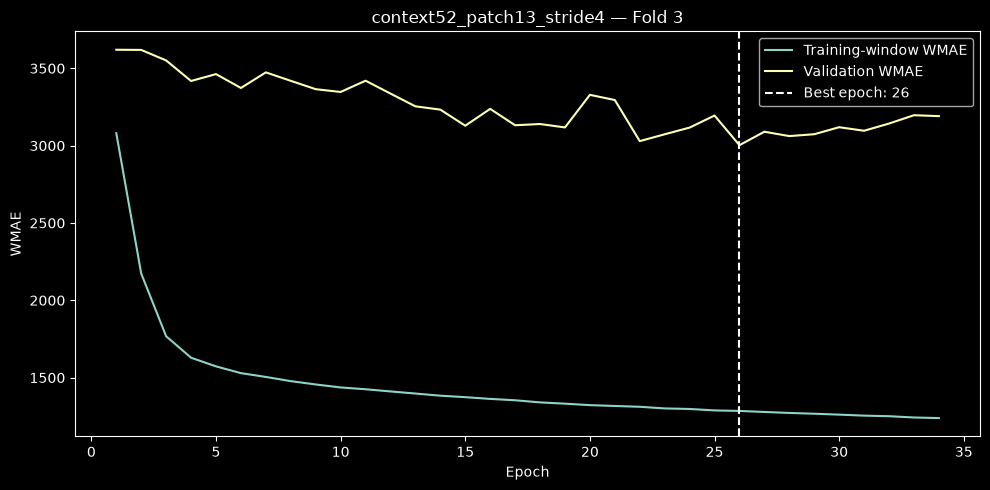

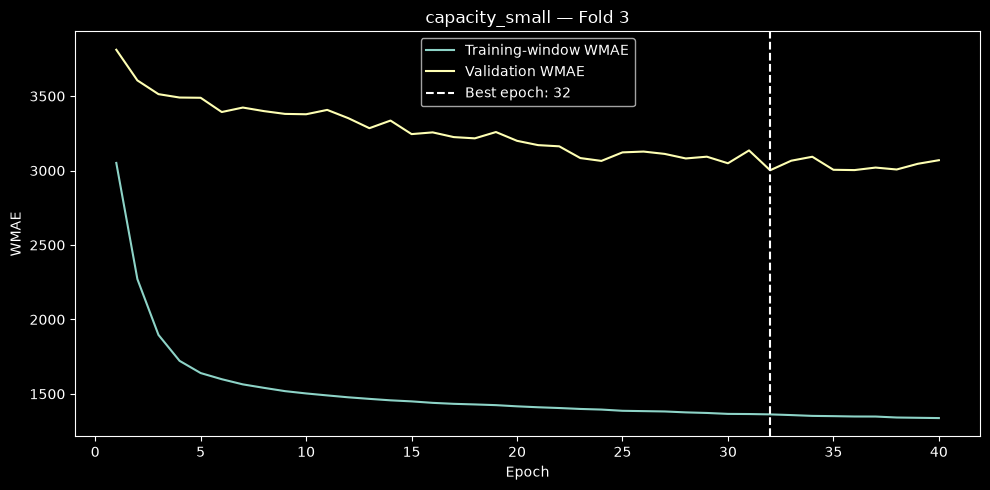

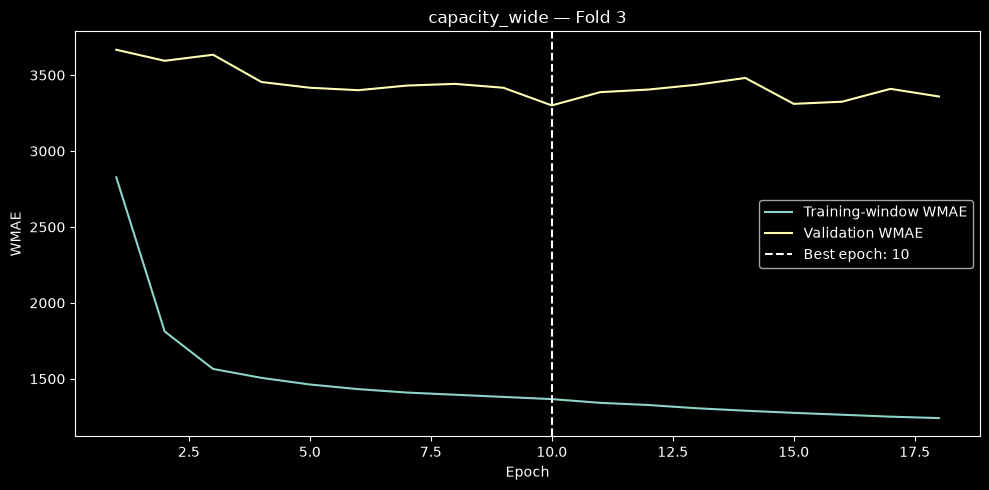

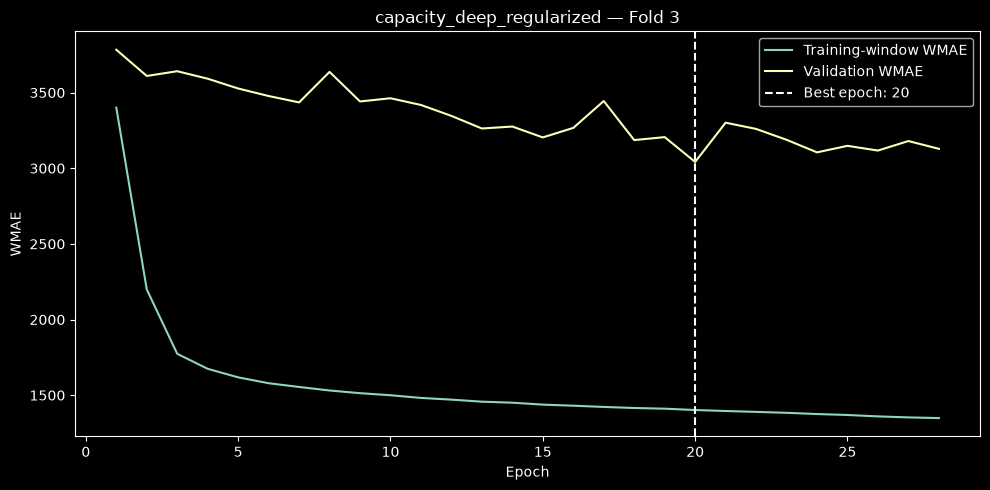

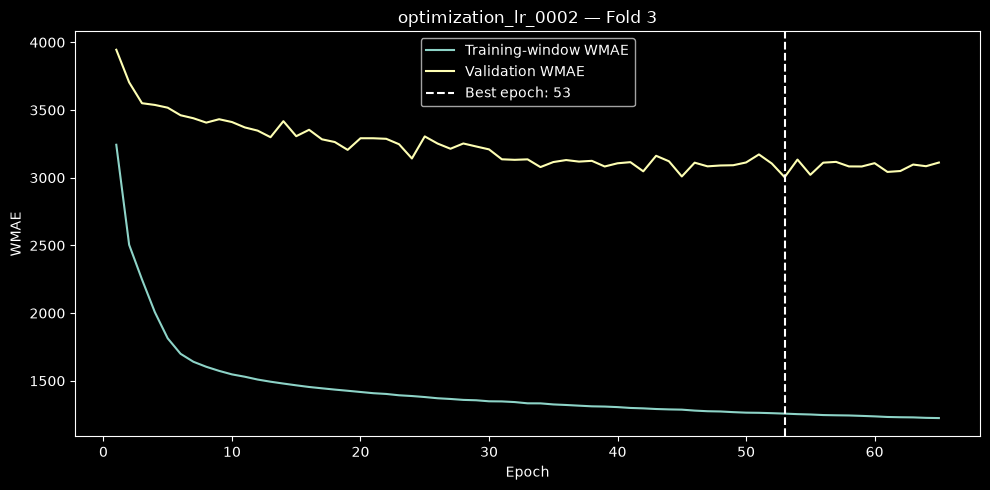

In [22]:
current_best_trial_id = (
    tuning_results.iloc[0][
        "trial_id"
    ]
)

diagnostic_trial_ids = [
    best_patch_trial_id,
    "capacity_small",
    "capacity_wide",
    "capacity_deep_regularized",
    "optimization_lr_0002",
]

if (
    current_best_trial_id
    not in diagnostic_trial_ids
):
    diagnostic_trial_ids.append(
        current_best_trial_id
    )

diagnostic_trial_ids = list(
    dict.fromkeys(
        diagnostic_trial_ids
    )
)

diagnostic_fold = 3

learning_curve_figures = {}

for trial_id in diagnostic_trial_ids:
    history = trial_histories[
        trial_id
    ][diagnostic_fold]

    best_epoch = int(
        trial_fold_results[
            trial_id
        ]
        .loc[
            lambda dataframe:
            dataframe["fold"]
            == diagnostic_fold,
            "best_epoch",
        ]
        .iloc[0]
    )

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    axis.plot(
        history["epoch"],
        history[
            "train_window_wmae"
        ],
        label=(
            "Training-window WMAE"
        ),
    )

    axis.plot(
        history["epoch"],
        history[
            "validation_wmae"
        ],
        label="Validation WMAE",
    )

    axis.axvline(
        best_epoch,
        linestyle="--",
        label=(
            f"Best epoch: "
            f"{best_epoch}"
        ),
    )

    axis.set_title(
        f"{trial_id} — Fold "
        f"{diagnostic_fold}"
    )

    axis.set_xlabel("Epoch")
    axis.set_ylabel("WMAE")
    axis.legend()

    figure.tight_layout()
    plt.show()

    learning_curve_figures[
        trial_id
    ] = figure

## Best configuration selection

In [23]:
best_trial_id = (
    tuning_results.iloc[0][
        "trial_id"
    ]
)

best_trial = deepcopy(
    trial_registry[
        best_trial_id
    ]
)

best_trial_folds = (
    trial_fold_results[
        best_trial_id
    ]
)

final_epochs = max(
    1,
    int(
        np.median(
            best_trial_folds[
                "best_epoch"
            ]
        )
    ),
)

print(
    "Selected trial:",
    best_trial_id,
)

print(
    "CV WMAE:",
    tuning_results.iloc[0][
        "cv_wmae_mean"
    ],
)

print(
    "CV WMAE std:",
    tuning_results.iloc[0][
        "cv_wmae_std"
    ],
)

print(
    "Final epochs:",
    final_epochs,
)

best_trial

Selected trial: optimization_lr_0002
CV WMAE: 2203.521934654642
CV WMAE std: 575.8135546520513
Final epochs: 53


{'trial_id': 'optimization_lr_0002',
 'trial_name': 'learning_rate_0002',
 'capacity_profile': 'lower_learning_rate',
 'feature_set': 'target_only_context52_patch13_stride4_v1',
 'preprocessing': 'masked_panel_revin_v1',
 'input_length': 52,
 'patch_length': 13,
 'stride': 4,
 'd_model': 128,
 'n_heads': 4,
 'encoder_layers': 3,
 'd_ff': 256,
 'dropout': 0.1,
 'head_dropout': 0.1,
 'use_revin': True,
 'use_amp': True,
 'learning_rate': 0.0002,
 'weight_decay': 0.0001,
 'batch_size': 512,
 'max_epochs': 80,
 'patience': 12}

## Fixed-epoch final training

In [24]:
def train_final_model(
    configuration: dict,
    training_rows: pd.DataFrame,
    all_series: pd.DataFrame,
    number_of_epochs: int,
    run,
) -> tuple[
    nn.Module,
    dict,
    float,
    pd.DataFrame,
]:
    set_seed(DEFAULT_RANDOM_SEED)

    panel_state = build_panel_state(
        training_rows=training_rows,
        all_series=all_series,
    )

    dataset = PanelWindowDataset(
        panel_state=panel_state,
        input_length=configuration[
            "input_length"
        ],
        horizon=FORECAST_HORIZON,
        min_input_coverage=(
            MIN_INPUT_COVERAGE
        ),
    )

    generator = torch.Generator()

    generator.manual_seed(
        DEFAULT_RANDOM_SEED
    )

    loader = DataLoader(
        dataset,
        batch_size=configuration[
            "batch_size"
        ],
        shuffle=True,
        num_workers=0,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        generator=generator,
    )

    model = build_model(
        configuration
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=configuration[
            "learning_rate"
        ],
        weight_decay=configuration[
            "weight_decay"
        ],
    )

    scaler = None

    if trial_uses_amp(configuration):
        scaler = torch.amp.GradScaler(
            "cuda"
        )

    history = []
    fit_start = time.perf_counter()

    for epoch in range(
        1,
        number_of_epochs + 1,
    ):
        model.train()

        weighted_error_sum = 0.0
        weight_sum = 0.0

        for (
            input_values,
            input_mask,
            targets,
            target_mask,
            horizon_weights,
        ) in loader:
            input_values = input_values.to(
                DEVICE,
                non_blocking=True,
            )

            input_mask = input_mask.to(
                DEVICE,
                non_blocking=True,
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True,
            )

            target_mask = target_mask.to(
                DEVICE,
                non_blocking=True,
            )

            horizon_weights = (
                horizon_weights.to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with amp_context(configuration):
                predictions = model(
                    input_values,
                    input_mask,
                )

                loss = weighted_mae_loss(
                    predictions=predictions,
                    targets=targets,
                    target_mask=(
                        target_mask
                    ),
                    horizon_weights=(
                        horizon_weights
                    ),
                )

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite loss during "
                    "final PatchTST training."
                )

            if scaler is not None:
                scaler.scale(
                    loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRADIENT_CLIP_NORM,
                )

                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    GRADIENT_CLIP_NORM,
                )

                optimizer.step()

            with torch.no_grad():
                combined_weights = (
                    target_mask.float()
                    * horizon_weights.float()
                )

                raw_absolute_error = (
                    predictions.float()
                    - targets.float()
                ).abs()

                weighted_error_sum += (
                    raw_absolute_error
                    .mul(combined_weights)
                    .sum()
                    .item()
                )

                weight_sum += (
                    combined_weights
                    .sum()
                    .item()
                )

        train_window_wmae = (
            weighted_error_sum
            / max(weight_sum, 1.0)
        )

        history.append(
            {
                "epoch": epoch,
                "train_window_wmae": (
                    train_window_wmae
                ),
            }
        )

        run.log(
            {
                "epoch": epoch,
                "train_window_wmae": (
                    train_window_wmae
                ),
            },
            step=epoch,
        )

        print(
            f"Epoch {epoch:02d}/"
            f"{number_of_epochs} | "
            f"train WMAE="
            f"{train_window_wmae:,.2f}"
        )

    fit_seconds = (
        time.perf_counter()
        - fit_start
    )

    return (
        model,
        panel_state,
        fit_seconds,
        pd.DataFrame(history),
    )

## Recursive 39-week forecasting

In [25]:
@torch.no_grad()
def recursive_forecast(
    model: nn.Module,
    panel_state: dict,
    holdout_rows: pd.DataFrame,
    configuration: dict,
) -> tuple[
    dict[str, float],
    pd.DataFrame,
]:
    model.eval()

    holdout_rows = (
        holdout_rows
        .sort_values(
            ["Date", "Store", "Dept"]
        )
        .reset_index(drop=True)
        .copy()
    )

    forecast_dates = pd.DatetimeIndex(
        holdout_rows["Date"]
        .drop_duplicates()
        .sort_values()
    )

    if (
        len(forecast_dates)
        % FORECAST_HORIZON
        != 0
    ):
        raise ValueError(
            "Holdout horizon must be "
            "divisible by 13."
        )

    input_length = configuration[
        "input_length"
    ]

    values_history = (
        panel_state["values"].copy()
    )

    mask_history = (
        panel_state["observed"].copy()
    )

    initial_coverage = (
        mask_history[
            :,
            -input_length:,
        ]
        .mean(axis=1)
    )

    eligible = (
        initial_coverage
        >= MIN_INPUT_COVERAGE
    )

    eligible_indices = np.flatnonzero(
        eligible
    )

    prediction_frames = []

    for block_start in range(
        0,
        len(forecast_dates),
        FORECAST_HORIZON,
    ):
        block_dates = forecast_dates[
            block_start:
            block_start
            + FORECAST_HORIZON
        ]

        block_predictions = np.zeros(
            (
                len(
                    panel_state[
                        "series_frame"
                    ]
                ),
                FORECAST_HORIZON,
            ),
            dtype=np.float32,
        )

        batch_size = configuration[
            "batch_size"
        ]

        for start in range(
            0,
            len(eligible_indices),
            batch_size,
        ):
            batch_indices = (
                eligible_indices[
                    start:
                    start + batch_size
                ]
            )

            batch_values = (
                torch.from_numpy(
                    values_history[
                        batch_indices,
                        -input_length:,
                    ]
                )
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            batch_mask = (
                torch.from_numpy(
                    mask_history[
                        batch_indices,
                        -input_length:,
                    ]
                )
                .to(
                    DEVICE,
                    non_blocking=True,
                )
            )

            with amp_context(configuration):
                batch_predictions = model(
                    batch_values,
                    batch_mask,
                )

            batch_predictions = (
                batch_predictions
                .float()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            if not np.isfinite(
                batch_predictions
            ).all():
                raise FloatingPointError(
                    "Non-finite recursive "
                    "forecast detected."
                )

            block_predictions[
                batch_indices
            ] = batch_predictions

        eligible_series = (
            panel_state[
                "series_frame"
            ]
            .iloc[eligible_indices]
            .reset_index(drop=True)
        )

        block_frame = (
            eligible_series
            .loc[
                eligible_series
                .index
                .repeat(
                    FORECAST_HORIZON
                )
            ]
            .reset_index(drop=True)
        )

        block_frame["Date"] = np.tile(
            block_dates.to_numpy(),
            len(eligible_series),
        )

        block_frame[
            "ModelPrediction"
        ] = (
            block_predictions[
                eligible_indices
            ]
            .reshape(-1)
        )

        prediction_frames.append(
            block_frame
        )

        block_mask = np.zeros_like(
            block_predictions,
            dtype=np.float32,
        )

        block_mask[
            eligible_indices
        ] = 1.0

        values_history = np.concatenate(
            [
                values_history,
                block_predictions,
            ],
            axis=1,
        )

        mask_history = np.concatenate(
            [
                mask_history,
                block_mask,
            ],
            axis=1,
        )

    model_predictions = pd.concat(
        prediction_frames,
        ignore_index=True,
    )

    result = holdout_rows.merge(
        model_predictions,
        on=[
            "Store",
            "Dept",
            "Date",
        ],
        how="left",
        validate="many_to_one",
    )

    fallback_predictions = (
        make_fallback_predictions(
            rows=result,
            panel_state=panel_state,
        )
    )

    model_mask = result[
        "ModelPrediction"
    ].notna()

    result["Prediction"] = np.where(
        model_mask,
        result["ModelPrediction"],
        fallback_predictions,
    )

    result["AbsoluteError"] = (
        result["Weekly_Sales"]
        - result["Prediction"]
    ).abs()

    metrics = {
        "wmae": weighted_mae(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result["Prediction"],
            is_holiday=result[
                "IsHoliday"
            ],
        ),
        "mae": mean_absolute_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result["Prediction"],
        ),
        "rmse": root_mean_squared_error(
            y_true=result[
                "Weekly_Sales"
            ],
            y_pred=result["Prediction"],
        ),
        "neural_coverage": float(
            model_mask.mean()
        ),
    }

    return metrics, result

## Final W&B training and holdout evaluation

In [26]:
best_cv_result = (
    tuning_results.iloc[0]
)

final_run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage="final",
    feature_set=best_trial[
        "feature_set"
    ],
    trial_name="best",
)

final_parameters = (
    build_common_parameters(
        architecture=ARCHITECTURE,
        stage="final",
        feature_set=best_trial[
            "feature_set"
        ],
        preprocessing=best_trial[
            "preprocessing"
        ],
        evaluation_scope=(
            "full_dataset"
        ),
        forecast_strategy=(
            "recursive_13x3"
        ),
        series_count=series_count,
        extra_parameters={
            **{
                key: value
                for key, value
                in best_trial.items()
                if key not in {
                    "trial_id",
                    "trial_name",
                    "feature_set",
                    "preprocessing",
                }
            },
            "final_epochs": (
                final_epochs
            ),
            "selected_trial_id": (
                best_trial_id
            ),
        },
    )
)

all_final_series = pd.concat(
    [
        final_split.train[
            ["Store", "Dept"]
        ],
        final_split.validation[
            ["Store", "Dept"]
        ],
    ],
    ignore_index=True,
)


with wandb_run(
    run_name=final_run_name,
    group=WANDB_GROUP,
    job_type="final_training",
    config=final_parameters,
    tags=[
        "patchtst",
        "final",
        "full_dataset",
    ],
) as final_run:
    (
        final_model,
        final_panel_state,
        final_fit_seconds,
        final_training_history,
    ) = train_final_model(
        configuration=best_trial,
        training_rows=(
            final_split.train
        ),
        all_series=all_final_series,
        number_of_epochs=(
            final_epochs
        ),
        run=final_run,
    )

    predict_start = (
        time.perf_counter()
    )

    (
        holdout_metrics,
        holdout_prediction_frame,
    ) = recursive_forecast(
        model=final_model,
        panel_state=(
            final_panel_state
        ),
        holdout_rows=(
            final_split.validation
        ),
        configuration=best_trial,
    )

    final_predict_seconds = (
        time.perf_counter()
        - predict_start
    )

    final_metrics = {
        "cv_wmae_mean": float(
            best_cv_result[
                "cv_wmae_mean"
            ]
        ),
        "cv_wmae_std": float(
            best_cv_result[
                "cv_wmae_std"
            ]
        ),
        "holdout_wmae": float(
            holdout_metrics["wmae"]
        ),
        "holdout_mae": float(
            holdout_metrics["mae"]
        ),
        "holdout_rmse": float(
            holdout_metrics["rmse"]
        ),
    }

    holdout_dates = (
        holdout_prediction_frame[
            "Date"
        ]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    date_to_block = {
        date: (
            index
            // FORECAST_HORIZON
            + 1
        )
        for index, date in enumerate(
            holdout_dates
        )
    }

    holdout_prediction_frame[
        "forecast_block"
    ] = (
        holdout_prediction_frame[
            "Date"
        ].map(date_to_block)
    )

    block_rows = []

    for (
        block_number,
        group,
    ) in holdout_prediction_frame.groupby(
        "forecast_block"
    ):
        block_rows.append(
            {
                "forecast_block": (
                    int(block_number)
                ),
                "rows": len(group),
                "wmae": weighted_mae(
                    y_true=group[
                        "Weekly_Sales"
                    ],
                    y_pred=group[
                        "Prediction"
                    ],
                    is_holiday=group[
                        "IsHoliday"
                    ],
                ),
                "mae": float(
                    group[
                        "AbsoluteError"
                    ].mean()
                ),
            }
        )

    recursive_block_diagnostics = (
        pd.DataFrame(block_rows)
    )

    holiday_diagnostics = (
        holdout_prediction_frame
        .groupby("IsHoliday")
        .agg(
            rows=(
                "Prediction",
                "size",
            ),
            mean_actual=(
                "Weekly_Sales",
                "mean",
            ),
            mean_prediction=(
                "Prediction",
                "mean",
            ),
            mean_absolute_error=(
                "AbsoluteError",
                "mean",
            ),
        )
        .reset_index()
    )

    department_diagnostics = (
        holdout_prediction_frame
        .groupby("Dept")
        .agg(
            rows=(
                "Prediction",
                "size",
            ),
            mean_absolute_error=(
                "AbsoluteError",
                "mean",
            ),
            total_absolute_error=(
                "AbsoluteError",
                "sum",
            ),
        )
        .sort_values(
            "total_absolute_error",
            ascending=False,
        )
        .reset_index()
    )

    final_run.summary.update(
        {
            **final_metrics,
            "neural_coverage": (
                holdout_metrics[
                    "neural_coverage"
                ]
            ),
            "fit_seconds": (
                final_fit_seconds
            ),
            "predict_seconds": (
                final_predict_seconds
            ),
            "final_epochs": (
                final_epochs
            ),
            "parameter_count": (
                count_parameters(
                    final_model
                )
            ),
            "patch_count": (
                calculate_patch_count(
                    best_trial
                )
            ),
        }
    )

    for row in block_rows:
        block_number = row[
            "forecast_block"
        ]

        final_run.summary[
            f"recursive_block_"
            f"{block_number}_wmae"
        ] = row["wmae"]

    prediction_sample = (
        holdout_prediction_frame
        .sample(
            n=min(
                5000,
                len(
                    holdout_prediction_frame
                ),
            ),
            random_state=(
                DEFAULT_RANDOM_SEED
            ),
        )
    )

    final_run.log(
        {
            "holdout_prediction_sample": (
                wandb.Table(
                    dataframe=(
                        prediction_sample
                    )
                )
            ),
            "tuning_results": (
                wandb.Table(
                    dataframe=(
                        tuning_results
                    )
                )
            ),
            "recursive_blocks": (
                wandb.Table(
                    dataframe=(
                        recursive_block_diagnostics
                    )
                )
            ),
        }
    )

    with TemporaryDirectory() as (
        temporary_directory
    ):
        temporary_path = Path(
            temporary_directory
        )

        checkpoint_path = (
            temporary_path
            / "patchtst_final.pt"
        )

        tuning_path = (
            temporary_path
            / "tuning_results.csv"
        )

        predictions_path = (
            temporary_path
            / "holdout_predictions.csv"
        )

        history_path = (
            temporary_path
            / "training_history.csv"
        )

        blocks_path = (
            temporary_path
            / "recursive_blocks.csv"
        )

        holiday_path = (
            temporary_path
            / "holiday_diagnostics.csv"
        )

        department_path = (
            temporary_path
            / "department_diagnostics.csv"
        )

        configuration_path = (
            temporary_path
            / "configuration.json"
        )

        checkpoint = {
            "model_state_dict": {
                key: value
                .detach()
                .cpu()
                for key, value
                in final_model
                .state_dict()
                .items()
            },
            "model_configuration": (
                best_trial
            ),
            "forecast_horizon": (
                FORECAST_HORIZON
            ),
            "final_epochs": (
                final_epochs
            ),
            "series_frame": (
                final_panel_state[
                    "series_frame"
                ]
            ),
            "history_values": (
                final_panel_state[
                    "values"
                ][
                    :,
                    -best_trial[
                        "input_length"
                    ]:,
                ]
            ),
            "history_mask": (
                final_panel_state[
                    "observed"
                ][
                    :,
                    -best_trial[
                        "input_length"
                    ]:,
                ]
            ),
            "training_end_date": str(
                final_split.train[
                    "Date"
                ].max()
            ),
        }

        torch.save(
            checkpoint,
            checkpoint_path,
        )

        tuning_results.to_csv(
            tuning_path,
            index=False,
        )

        holdout_prediction_frame.to_csv(
            predictions_path,
            index=False,
        )

        final_training_history.to_csv(
            history_path,
            index=False,
        )

        recursive_block_diagnostics.to_csv(
            blocks_path,
            index=False,
        )

        holiday_diagnostics.to_csv(
            holiday_path,
            index=False,
        )

        department_diagnostics.to_csv(
            department_path,
            index=False,
        )

        configuration_path.write_text(
            json.dumps(
                final_parameters,
                indent=2,
                default=str,
            ),
            encoding="utf-8",
        )

        reloaded_checkpoint = torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=False,
        )

        reloaded_model = build_model(
            reloaded_checkpoint[
                "model_configuration"
            ]
        ).to(DEVICE)

        reloaded_model.load_state_dict(
            reloaded_checkpoint[
                "model_state_dict"
            ]
        )

        reloaded_model.eval()
        final_model.eval()

        sample_values = (
            torch.from_numpy(
                final_panel_state[
                    "values"
                ][
                    :32,
                    -best_trial[
                        "input_length"
                    ]:,
                ]
            )
            .to(DEVICE)
        )

        sample_mask = (
            torch.from_numpy(
                final_panel_state[
                    "observed"
                ][
                    :32,
                    -best_trial[
                        "input_length"
                    ]:,
                ]
            )
            .to(DEVICE)
        )

        with torch.no_grad():
            original_sample = (
                final_model(
                    sample_values,
                    sample_mask,
                )
            )

            reloaded_sample = (
                reloaded_model(
                    sample_values,
                    sample_mask,
                )
            )

        reload_max_abs_diff = float(
            (
                original_sample
                - reloaded_sample
            )
            .abs()
            .max()
            .item()
        )

        np.testing.assert_allclose(
            original_sample
            .detach()
            .cpu()
            .numpy(),
            reloaded_sample
            .detach()
            .cpu()
            .numpy(),
            rtol=1e-6,
            atol=1e-6,
        )

        final_run.summary[
            "checkpoint_reload_"
            "max_abs_diff"
        ] = reload_max_abs_diff

        artifact = wandb.Artifact(
            name=(
                "patchtst-final-model"
            ),
            type="model",
            metadata={
                **final_metrics,
                "selected_trial_id": (
                    best_trial_id
                ),
                "final_epochs": (
                    final_epochs
                ),
                "neural_coverage": (
                    holdout_metrics[
                        "neural_coverage"
                    ]
                ),
            },
        )

        for artifact_path in [
            checkpoint_path,
            tuning_path,
            predictions_path,
            history_path,
            blocks_path,
            holiday_path,
            department_path,
            configuration_path,
        ]:
            artifact.add_file(
                str(artifact_path)
            )

        final_run.log_artifact(
            artifact
        )


print("Final run:", final_run_name)
print(final_metrics)

print(
    "Neural coverage:",
    f"{holdout_metrics['neural_coverage']:.2%}",
)

wandb: setting up run 89pjuqu4
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /home/xizusha/Documents/ML/walmart-store-sales-forecasting/notebooks/wandb/run-20260711_230014-89pjuqu4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run patchtst__final__target_only_context52_patch13_stride4_v1__best__s42
wandb: ⭐️ View project at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting
wandb: 🚀 View run at https://wandb.ai/lkhiz23-free-university-of-tbilisi-/walmart-store-sales-forecasting/runs/89pjuqu4


Epoch 01/53 | train WMAE=3,308.66
Epoch 02/53 | train WMAE=2,574.17
Epoch 03/53 | train WMAE=2,222.98
Epoch 04/53 | train WMAE=1,964.91
Epoch 05/53 | train WMAE=1,850.06
Epoch 06/53 | train WMAE=1,785.51
Epoch 07/53 | train WMAE=1,743.02
Epoch 08/53 | train WMAE=1,712.12
Epoch 09/53 | train WMAE=1,687.70
Epoch 10/53 | train WMAE=1,659.14
Epoch 11/53 | train WMAE=1,638.45
Epoch 12/53 | train WMAE=1,622.60
Epoch 13/53 | train WMAE=1,610.33
Epoch 14/53 | train WMAE=1,596.42
Epoch 15/53 | train WMAE=1,587.16
Epoch 16/53 | train WMAE=1,575.97
Epoch 17/53 | train WMAE=1,565.29
Epoch 18/53 | train WMAE=1,554.55
Epoch 19/53 | train WMAE=1,550.29
Epoch 20/53 | train WMAE=1,541.80
Epoch 21/53 | train WMAE=1,531.42
Epoch 22/53 | train WMAE=1,525.80
Epoch 23/53 | train WMAE=1,519.34
Epoch 24/53 | train WMAE=1,511.41
Epoch 25/53 | train WMAE=1,506.27
Epoch 26/53 | train WMAE=1,500.58
Epoch 27/53 | train WMAE=1,490.06
Epoch 28/53 | train WMAE=1,492.61
Epoch 29/53 | train WMAE=1,480.11
Epoch 30/53 | 

wandb: updating run metadata; uploading artifact run-89pjuqu4-holdout_prediction_sample; uploading artifact run-89pjuqu4-tuning_results; uploading artifact run-89pjuqu4-recursive_blocks; uploading artifact patchtst-final-model
wandb: uploading artifact run-89pjuqu4-holdout_prediction_sample; uploading artifact run-89pjuqu4-tuning_results; uploading artifact run-89pjuqu4-recursive_blocks; uploading artifact patchtst-final-model
wandb: uploading artifact run-89pjuqu4-holdout_prediction_sample; uploading artifact patchtst-final-model
wandb: uploading artifact patchtst-final-model
wandb: uploading artifact patchtst-final-model; uploading media/table/holdout_prediction_sample_53_b43302498cb487f42cba.table.json; uploading media/table/tuning_results_53_d4bc4ebc94a95166b263.table.json; uploading media/table/recursive_blocks_53_dfb6739ab23fe154d34a.table.json; uploading wandb-summary.json (+ 1 more)
wandb: uploading artifact patchtst-final-model; uploading media/table/holdout_prediction_sample_

Final run: patchtst__final__target_only_context52_patch13_stride4_v1__best__s42
{'cv_wmae_mean': 2203.521934654642, 'cv_wmae_std': 575.8135546520513, 'holdout_wmae': 1734.998474889725, 'holdout_mae': 1725.4224217376695, 'holdout_rmse': 3695.1198564771025}
Neural coverage: 95.75%


## Holdout diagnostics

In [27]:
recursive_block_diagnostics

,forecast_block,rows,wmae,mae
0,1,38685,"1,780.7482","1,801.6538"
1,2,38373,"1,649.0544","1,649.0544"
2,3,38530,"1,754.4239","1,724.9412"


In [28]:
holiday_diagnostics

,IsHoliday,rows,mean_actual,mean_prediction,mean_absolute_error
0,False,109621,"15,808.0926","15,366.9746","1,722.3768"
1,True,5967,"16,480.5543","15,805.8184","1,781.3734"


In [29]:
department_diagnostics.head(15)

,Dept,rows,mean_absolute_error,total_absolute_error
0,38,1755,"6,777.4512","11,894,426.8148"
1,72,1656,"6,168.3201","10,214,738.1509"
2,92,1755,"5,780.1278","10,144,124.2034"
3,1,1755,"4,982.5587","8,744,390.6051"
4,95,1755,"4,203.0835","7,376,411.4990"
5,16,1755,"3,748.6536","6,578,887.0597"
6,7,1755,"3,407.6830","5,980,483.7130"
7,90,1755,"3,301.9588","5,794,937.6899"
8,18,1346,"4,149.2183","5,584,847.8453"
9,9,1748,"3,091.3398","5,403,662.0534"


## Save final architecture result

In [30]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=final_run_name,
    stage="final",
    tracker="wandb",
    feature_set=best_trial[
        "feature_set"
    ],
    preprocessing=best_trial[
        "preprocessing"
    ],
    evaluation_scope=(
        "full_dataset"
    ),
    forecast_strategy=(
        "recursive_13x3"
    ),
    series_count=series_count,
    metrics=final_metrics,
    fit_seconds=(
        final_fit_seconds
    ),
    predict_seconds=(
        final_predict_seconds
    ),
    notes=(
        "Global supervised PatchTST "
        "with shared channel-independent "
        "encoder, masked patch inputs, "
        "instance normalization and "
        "weighted MAE training. "
        "Configuration selected by "
        "mean CV WMAE."
    ),
)

save_architecture_result(
    result_row
)

pd.DataFrame([result_row])

,architecture,run_name,stage,tracker,feature_set,preprocessing,validation_id,data_version,evaluation_scope,forecast_strategy,series_count,random_seed,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds,notes
0,patchtst,patchtst__final__target_only_context52_patch13...,final,wandb,target_only_context52_patch13_stride4_v1,masked_panel_revin_v1,expanding_3x13_holdout_39_v1,processed_v1,full_dataset,recursive_13x3,3306,42,"2,203.5219",575.8136,"1,734.9985","1,725.4224","3,695.1199",382.3258,0.1563,Global supervised PatchTST with shared channel...


## Register the final model

In [33]:
ENTITY = (
    "lkhiz23-free-university-of-tbilisi-"
)

PROJECT = (
    "walmart-store-sales-forecasting"
)

SOURCE_ARTIFACT = (
    f"{ENTITY}/{PROJECT}/"
    "patchtst-final-model:v0"
)

REGISTRY_PATH = (
    "wandb-registry-walmart-models/"
    "PatchTST"
)


api = wandb.Api(
    overrides={
        "entity": ENTITY,
    }
)

source_artifact = api.artifact(
    SOURCE_ARTIFACT
)

linked_artifact = source_artifact.link(
    target_path=REGISTRY_PATH,
    aliases=["best"],
)

print(
    "Source artifact:",
    source_artifact.name,
)

print(
    "Linked to:",
    f"{REGISTRY_PATH}:best",
)

Source artifact: patchtst-final-model:v0
Linked to: wandb-registry-walmart-models/PatchTST:best
